# Grid Pathfinding Visualization Demo

This notebook demonstrates the grid pathfinding experiment framework with visualization capabilities.

## Overview

The framework supports two modes:
- **Visual Mode**: Small grids (~50×50) with frontier tracking for animations
- **Benchmark Mode**: Large grids (up to 1000×1000) for performance analysis

## Features

- Interactive expansion animations
- Path visualization and comparison
- Performance metrics analysis
- Convergence curve plotting
- Configurable algorithm parameters

## 1. Setup and Imports

In [1]:
# Import required libraries
import sys
import os
import IPython
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
import pandas as pd
from pathlib import Path

# Add src to path
src_path = Path.cwd().parent
sys.path.insert(0, str(src_path))
print("Added to path:", src_path)

# Import custom modules
from experiments.grid_experiment import GridExperiment
from problems.discrete import SPProblem
from notebooks.grid_visualization_example import (
    load_trace, create_grid_animation, plot_path_comparison,
    plot_performance_comparison, plot_convergence_comparison
)
from utils.configHelper import load_config

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ All libraries imported successfully")
print(f"✓ Working directory: {os.getcwd()}")
print(f"✓ Source path: {src_path}")

Added to path: D:\CODE\AI\AI1_search-algorithms\src
✓ All libraries imported successfully
✓ Working directory: D:\CODE\AI\AI1_search-algorithms\src\notebooks
✓ Source path: D:\CODE\AI\AI1_search-algorithms\src


## 2. Load Configuration and Test Data

In [2]:
# Load configuration
config = load_config('../utils/config.json')
print("Configuration loaded:")
print(f"- Grid problem: {config['problems']['grid']}")

# Load test problem from file
test_file = src_path / 'tests' / 'SP' / 'test_1.txt'
if test_file.exists():
    problem = SPProblem(str(test_file))
    print(f"\n✓ Test problem loaded from {test_file}")
    print(f"  Grid size: {problem.n} × {problem.m}")
    print(f"  Start: {problem.start_node}")
    print(f"  End: {problem.end_node}")
    print(f"  Obstacles: {np.sum(problem.grid == 1)}")
    print(f"  Open cells: {np.sum(problem.grid == 0)}")
else:
    print(f"✗ Test file not found: {test_file}")
    print("Creating a small random grid for demonstration...")
    problem = SPProblem.from_array(
        np.array([[0, 0, 0, 1, 0],
                  [1, 0, 0, 1, 0],
                  [0, 0, 1, 0, 0],
                  [0, 1, 0, 0, 0],
                  [0, 0, 0, 0, 0]], dtype=int),
        (0, 0), (4, 4)
    )

Configuration loaded:
- Grid problem: {'name': 'Grid Shortest Path (SP)', 'type': 'discrete', 'test_dir': 'tests/SP', 'test_pattern': 'test_*.txt', 'description': 'Find shortest path in grid maze from S to E', 'metrics': ['best_fitness', 'nodes_expanded', 'execution_time']}

✓ Test problem loaded from D:\CODE\AI\AI1_search-algorithms\src\tests\SP\test_1.txt
  Grid size: 19 × 19
  Start: (0, 1)
  End: (18, 17)
  Obstacles: 6
  Open cells: 355


## 3. Initialize Grid Experiment

✓ GridExperiment initialized
  Grid shape: (19, 19)
  Start node: (0, 1)
  End node: (18, 17)


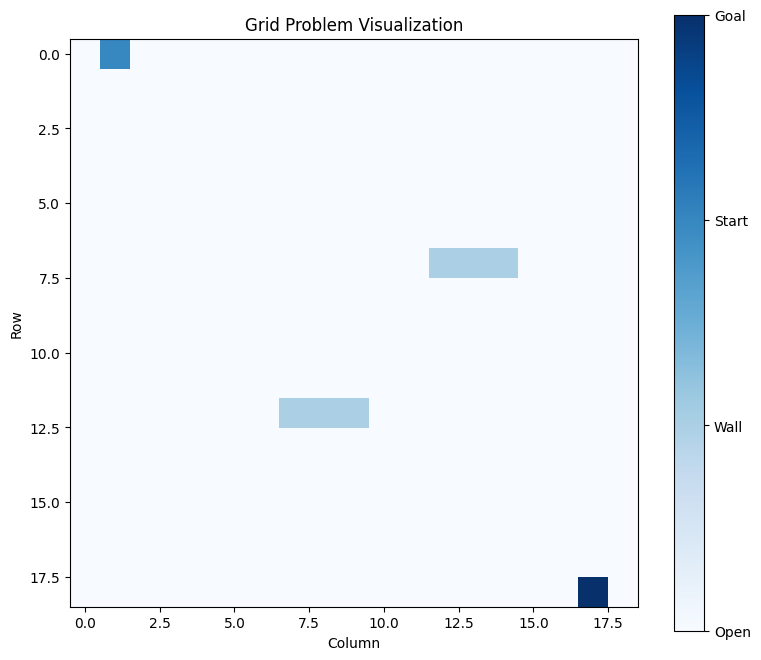

In [3]:
# Create experiment instance
experiment = GridExperiment(problem)

print("✓ GridExperiment initialized")
print(f"  Grid shape: {experiment.problem.grid.shape}")
print(f"  Start node: {experiment.problem.start_node}")
print(f"  End node: {experiment.problem.end_node}")

# Display the grid
fig, ax = plt.subplots(figsize=(8, 8))
grid_display = experiment.problem.grid.copy()
grid_display[experiment.problem.start_node] = 2  # Start
grid_display[experiment.problem.end_node] = 3    # End

im = ax.imshow(grid_display, cmap='Blues', origin='upper')
ax.set_title('Grid Problem Visualization')
ax.set_xlabel('Column')
ax.set_ylabel('Row')

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_ticks([0, 1, 2, 3])
cbar.set_ticklabels(['Open', 'Wall', 'Start', 'Goal'])

plt.tight_layout()
plt.show()

## 4. Run Visual Experiment with Frontier Tracking

In [4]:
# Define algorithms to test
algorithms = ['DFS', 'AStarSearch']

print(f"Running visual experiment with algorithms: {algorithms}")
print("This will track frontier expansion for animation...")

# Run visual experiment (with frontier recording)
trace = experiment.visualize(algorithms, trace_path='demo_trace.pkl')

print("\n✓ Visual experiment completed")
print(f"  Trace saved to: demo_trace.pkl")
print(f"  Algorithms run: {list(trace['algorithms'].keys())}")

# Display results summary
for algo_name, result in trace['algorithms'].items():
    path_length = result.get('path_length', 'N/A')
    nodes_expanded = result.get('nodes_expanded', 'N/A')
    time_taken = result.get('execution_time_seconds', 'N/A')
    explored_len = len(result.get('explored_nodes_history', []))
    frontier_len = len(result.get('frontier_history', []))
    
    print(f"\n{algo_name}:")
    print(f"  Path length: {path_length}")
    print(f"  Nodes expanded: {nodes_expanded}")
    print(f"  Execution time: {time_taken}s")
    print(f"  Explored history: {explored_len} steps")
    print(f"  Frontier history: {frontier_len} steps")

Running visual experiment with algorithms: ['DFS', 'AStarSearch']
This will track frontier expansion for animation...
Running visual experiment on 19x19 grid...
Running DFS...
  ✓ DFS completed
Running AStarSearch...
  ✓ AStarSearch completed
Trace saved to: demo_trace.pkl

✓ Visual experiment completed
  Trace saved to: demo_trace.pkl
  Algorithms run: ['DFS', 'AStarSearch']

DFS:
  Path length: 243
  Nodes expanded: 318
  Execution time: 0.007993936538696289s
  Explored history: 318 steps
  Frontier history: 345 steps

AStarSearch:
  Path length: 35
  Nodes expanded: 317
  Execution time: 0.002988576889038086s
  Explored history: 317 steps
  Frontier history: 317 steps


## 5. Create Expansion Animation

In [ ]:
%matplotlib inline
# Create animation for BFS
print("Creating expansion animation for BFS...")
anim_bfs = create_grid_animation(trace, 'DFS', interval=100, save_path="videos.gif")

# Note: In a real notebook, you would see the animation here
# For static display, we can show a few frames
print("\nAnimation created! In an interactive notebook, you would see the expansion animation.")
print("The animation shows:")
print("- Blue: Open cells")
print("- Black: Walls")
print("- Red: Start")
print("- Yellow: Goal")
print("- Green: Explored nodes")
print("- Orange: Frontier nodes")
print("- Purple: Final path")

# Display the animation
from IPython.display import HTML
HTML(anim_bfs.to_html5_video())

Creating expansion animation for BFS...


## 6. Compare Final Paths

In [ ]:
# Plot path comparison
fig = plot_path_comparison(trace, algorithms)
plt.show()

print("Path comparison plot shows the final paths found by each algorithm.")
print("Note: A* should find the optimal path, while other algorithms may find longer paths.")

## 7. Run Benchmark Experiment

In [ ]:
# Run benchmark on the same grid
print("Running benchmark experiment...")
benchmark_df = experiment.benchmark(algorithms + ['GreedyBestFirst'], csv_path='demo_benchmark.csv')

print("\n✓ Benchmark completed")
print("Results saved to: demo_benchmark.csv")

# Display the results
print("\nBenchmark Results:")
print(benchmark_df.to_string(index=False))

## 8. Performance Analysis

In [ ]:
# Create performance comparison plots
fig = plot_performance_comparison('demo_benchmark.csv')
plt.show()

print("Performance comparison shows:")
print("- Path Length: How optimal is each solution?")
print("- Nodes Expanded: Computational complexity")
print("- Execution Time: Speed comparison")
print("\nNote: A* typically finds optimal paths but may expand more nodes than greedy approaches.")

## 9. Advanced: Larger Grid Benchmark

In [ ]:
# Create a larger random grid for benchmark comparison
print("Creating larger random grid for benchmark...")
large_experiment = GridExperiment.random(rows=100, cols=100, obstacle_prob=0.3, seed=42)

print(f"Large grid: {large_experiment.problem.n} × {large_experiment.problem.m}")
print(f"Obstacle probability: 30%")

# Run benchmark on large grid
large_benchmark = large_experiment.benchmark(
    ['BFS', 'AStarSearch', 'GreedyBestFirst'], 
    csv_path='large_benchmark.csv'
)

print("\nLarge grid benchmark results:")
print(large_benchmark[['algorithm', 'best_fitness', 'nodes_expanded', 'execution_time_seconds']].to_string(index=False))

## 10. Convergence Analysis (Metaheuristics)

In [ ]:
# For metaheuristic algorithms, we can analyze convergence
print("Running experiment with metaheuristic algorithms...")

# Create trace with metaheuristics
meta_trace = experiment.visualize(['GA_Grid', 'ACO_Grid'], trace_path='meta_trace.pkl')

# Plot convergence curves
fig = plot_convergence_comparison('meta_trace.pkl')
plt.show()

print("Convergence analysis shows how metaheuristic algorithms improve over iterations.")
print("GA_Grid and ACO_Grid should show decreasing fitness values over time.")

## 11. Interactive Exploration

In [ ]:
# Interactive widgets for exploration (if ipywidgets is available)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    
    # Algorithm selector
    algo_selector = widgets.SelectMultiple(
        options=['BFS', 'DFS', 'UCS', 'GreedyBestFirst', 'AStarSearch', 'GA_Grid', 'ACO_Grid'],
        value=['BFS', 'AStarSearch'],
        description='Algorithms:',
        disabled=False
    )
    
    # Grid size selector
    size_selector = widgets.IntSlider(
        value=50,
        min=10,
        max=200,
        step=10,
        description='Grid Size:',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='d'
    )
    
    # Obstacle probability
    obstacle_slider = widgets.FloatSlider(
        value=0.25,
        min=0.1,
        max=0.5,
        step=0.05,
        description='Obstacles:',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='.1%'
    )
    
    # Run button
    run_button = widgets.Button(
        description='Run Experiment',
        disabled=False,
        button_style='',
        tooltip='Click to run the experiment',
        icon='play'
    )
    
    output_area = widgets.Output()
    
    def run_experiment(b):
        with output_area:
            clear_output()
            algorithms = list(algo_selector.value)
            grid_size = size_selector.value
            obstacle_prob = obstacle_slider.value
            
            print(f"Running experiment with:")
            print(f"  Algorithms: {algorithms}")
            print(f"  Grid size: {grid_size}×{grid_size}")
            print(f"  Obstacle probability: {obstacle_prob:.1%}")
            
            # Create random experiment
            exp = GridExperiment.random(grid_size, grid_size, obstacle_prob, seed=42)
            
            # Run benchmark
            df = exp.benchmark(algorithms)
            
            # Display results
            print("\nResults:")
            print(df[['algorithm', 'best_fitness', 'nodes_expanded', 'execution_time_seconds']].to_string(index=False))
    
    run_button.on_click(run_experiment)
    
    # Display widgets
    display(algo_selector, size_selector, obstacle_slider, run_button, output_area)
    
except ImportError:
    print("ipywidgets not available. Install with: pip install ipywidgets")
    print("Interactive exploration features are not available.")

## Summary

This notebook demonstrated the complete grid pathfinding experiment framework:

### Key Features Covered:

1. **Problem Loading**: Reading grids from test files or generating random grids
2. **Visual Experiments**: Frontier tracking and expansion animations
3. **Benchmark Experiments**: Performance metrics collection and analysis
4. **Visualization**: Path comparisons, performance plots, convergence curves
5. **Interactive Exploration**: Configurable experiments with widgets

### Algorithms Demonstrated:
- **Classic Search**: BFS, DFS, UCS, Greedy Best-First, A*
- **Metaheuristics**: GA_Grid, ACO_Grid

### Analysis Metrics:
- **Solution Quality**: Path length optimality
- **Computational Complexity**: Nodes expanded, execution time
- **Search Strategy**: Exploration vs exploitation patterns

### Usage Patterns:

```bash
# Visual mode (small grids)
python experiments/grid_experiment.py --mode visual --grid-file tests/SP/test_1.txt --algorithms BFS,A* --out trace.pkl

# Benchmark mode (large grids)
python experiments/grid_experiment.py --mode benchmark --rows 500 --cols 500 --algorithms BFS,A*,GA_Grid --out results.csv
```

### Next Steps:

1. Experiment with different grid sizes and obstacle densities
2. Compare algorithm performance across multiple test cases
3. Analyze the trade-offs between optimality and computational efficiency
4. Extend to multi-objective pathfinding (shortest path + minimal turns)

The framework is designed to be extensible - you can easily add new algorithms, problems, or visualization types!